In [1]:
from google.colab import files
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

uploaded = files.upload()
for file_name in uploaded.keys():
    print(f"Arquivo carregado: {file_name}")

# Definindo o data frame (df):
df = pd.read_excel('IPCA_ANALISAR.xlsx')

# Removendo espaços nos nomes
df.columns = df.columns.str.strip()

# Lista de nomes das colunas:
print("Nomes das colunas no DataFrame:")
print(df.columns.tolist())

Saving IPCA_ANALISAR.xlsx to IPCA_ANALISAR.xlsx
Arquivo carregado: IPCA_ANALISAR.xlsx
Nomes das colunas no DataFrame:
['Período', 'IPCA']


In [2]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Definindo o data frame (df):
df = pd.read_excel('IPCA_ANALISAR.xlsx')

# Remover espaços dos nomes das colunas
df.columns = df.columns.str.strip()

# Lista de nomes das colunas:
print("Nomes das colunas no DataFrame:")
print(df.columns.tolist())

Nomes das colunas no DataFrame:
['Período', 'IPCA']


In [3]:
# Filtrar a base para datas a partir de janeiro de 2004

df['Período'] = pd.to_datetime(df['Período'])  # Converter para datetime
df = df[df['Período'] >= '2004-01-01']

# Verificar o novo DataFrame filtrado
print(df.head())
print(f"Novo tamanho da base: {df.shape}")

       Período  IPCA
108 2004-01-01  0.76
109 2004-02-01  0.61
110 2004-03-01  0.47
111 2004-04-01  0.37
112 2004-05-01  0.51
Novo tamanho da base: (251, 2)


In [4]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Definindo a função "criar_janelas"
def criar_janelas(data, janela):
    X, y = [], []
    for i in range(len(data) - janela):
        X.append(data[i:i + janela])
        y.append(data[i + janela])
    return np.array(X), np.array(y)

# Configuração de janela de tempo - NÃO NORMALIZAR AINDA (Viés)
janela = 6
dados = df['IPCA'].values

# Divisão de dados
split_train = int(0.7 * len(dados))  # 70% para treino
split_val = int(0.85 * len(dados))   # 15% para validação (70% + 15%)
# Divisão em treino, validação e teste
dados_train, dados_val, dados_test = dados[:split_train], dados[split_train:split_val], dados[split_val:]
# Normalizar os dados
scaler = MinMaxScaler()
# Ajuste e transformação para o conjunto de treino
dados_train_normalizado = scaler.fit_transform(dados_train.reshape(-1, 1))

# Aplicar a mesma transformação para validação e teste
dados_val_normalizado = scaler.transform(dados_val.reshape(-1, 1))
dados_test_normalizado = scaler.transform(dados_test.reshape(-1, 1))

# Criar janelas de tempo
X_train, y_train = criar_janelas(dados_train_normalizado, janela)
X_val, y_val = criar_janelas(dados_val_normalizado, janela)
X_test, y_test = criar_janelas(dados_test_normalizado, janela)

# Verificação dos tamanhos
print(f"Tamanho do Treino: {len(X_train)}")
print(f"Tamanho da Validação: {len(X_val)}")
print(f"Tamanho do Teste: {len(X_test)}")


Tamanho do Treino: 169
Tamanho da Validação: 32
Tamanho do Teste: 32


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2

# Modelo LSTM com Dropout e L2
model = Sequential([
    LSTM(50, activation='relu', kernel_regularizer=l2(0.005), input_shape=(janela, 1), return_sequences=False),
    Dropout(0.2),  # Dropout para regularização
    Dense(1)  # Saída com um único valor
])

# Compilando o modelo
model.compile(optimizer='adam', loss='mean_squared_error')

# Transformando os dados para LSTM
X_train_reshaped = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val_reshaped = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test_reshaped = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Configurando o callback de Early Stopping - evitar treino em excesso
early_stopping = EarlyStopping(
    monitor='val_loss',  # Métrica
    patience=10,         # Número de épocas sem melhora antes de parar
    restore_best_weights=True  # Restaura os pesos da melhor época
)

# Treinar o modelo com Early Stopping
history = model.fit(
    X_train_reshaped, y_train,
    epochs=140,
    batch_size=16,
    validation_data=(X_val_reshaped, y_val),
    callbacks=[early_stopping]  # Adicionar o callback
)


Epoch 1/140


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.2369 - val_loss: 0.2238
Epoch 2/140
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1684 - val_loss: 0.1541
Epoch 3/140
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0904 - val_loss: 0.0919
Epoch 4/140
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0428 - val_loss: 0.0773
Epoch 5/140
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0402 - val_loss: 0.0750
Epoch 6/140
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0389 - val_loss: 0.0762
Epoch 7/140
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0357 - val_loss: 0.0739
Epoch 8/140
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0394 - val_loss: 0.0729
Epoch 9/140
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0410 - val_loss: 0.0729
Epoch 10/140
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0338 - val_loss: 0.0716
Epoch 11/140
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0333 - val_loss: 0.0720
Epoch 12/140
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0344

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - loss: 0.0486
Erro no conjunto de teste (MSE): 0.04860573634505272
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


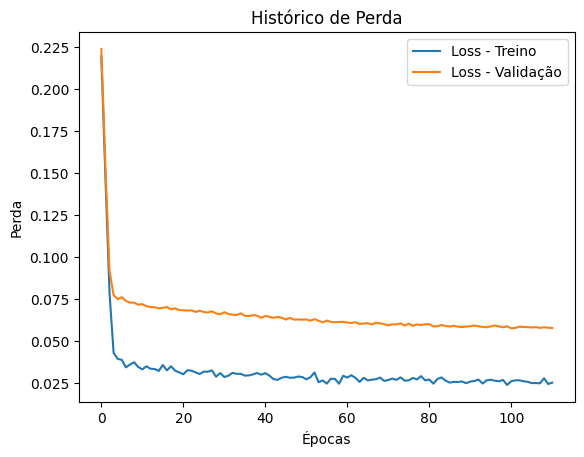

Métricas de Desempenho:
Treino - MSE: 0.0219, RMSE: 0.1480, MAE: 0.1120
Validação - MSE: 0.0561, RMSE: 0.2368, MAE: 0.2061
Teste - MSE: 0.0471, RMSE: 0.2170, MAE: 0.1549


In [6]:
# Avaliando no conjunto de teste
test_loss = model.evaluate(X_test_reshaped, y_test)
print(f"Erro no conjunto de teste (MSE): {test_loss}")

# Previsões para cada conjunto
y_train_pred = model.predict(X_train_reshaped)
y_val_pred = model.predict(X_val_reshaped)
y_test_pred = model.predict(X_test_reshaped)

# Visualizar histórico de treinamento
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Loss - Treino')
plt.plot(history.history['val_loss'], label='Loss - Validação')
plt.title('Histórico de Perda')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.show()

# Métricas de desempenho
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Função para calcular as métricas
def calcular_metricas(y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_pred)
    return mse, rmse, mae
# Calcular as métricas para cada conjunto
mse_train, rmse_train, mae_train = calcular_metricas(y_train, y_train_pred)
mse_val, rmse_val, mae_val = calcular_metricas(y_val, y_val_pred)
mse_test, rmse_test, mae_test = calcular_metricas(y_test, y_test_pred)

# Exibir métricas
print("Métricas de Desempenho:")
print(f"Treino - MSE: {mse_train:.4f}, RMSE: {rmse_train:.4f}, MAE: {mae_train:.4f}")
print(f"Validação - MSE: {mse_val:.4f}, RMSE: {rmse_val:.4f}, MAE: {mae_val:.4f}")
print(f"Teste - MSE: {mse_test:.4f}, RMSE: {rmse_test:.4f}, MAE: {mae_test:.4f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


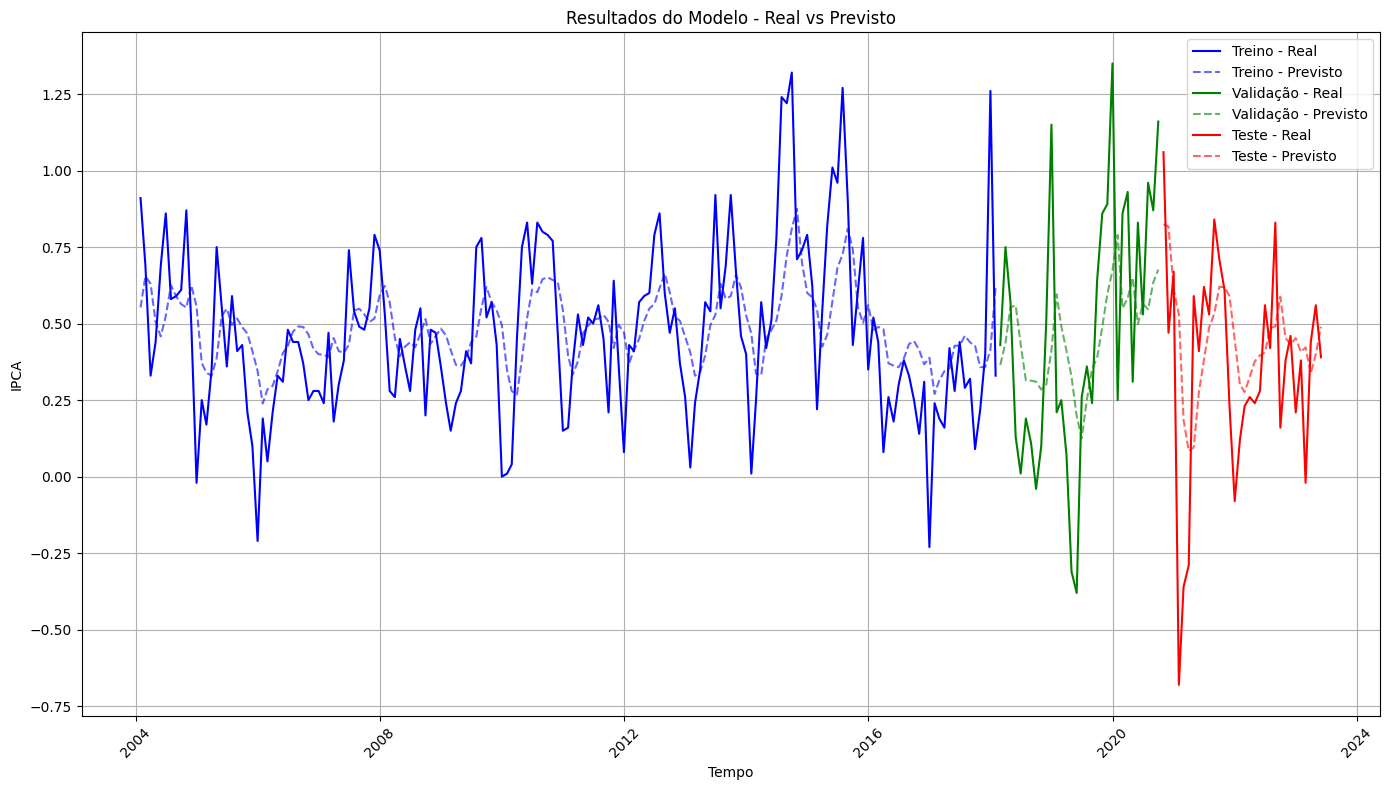

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Supondo que você tenha a data inicial para o seu conjunto de dados
# Ajuste a data inicial conforme seu caso
start_date = pd.to_datetime("2004-01-01")

# Obter previsões para os conjuntos de treino, validação e teste
y_train_pred = model.predict(X_train_reshaped)
y_val_pred = model.predict(X_val_reshaped)
y_test_pred = model.predict(X_test_reshaped)

# Reverter a normalização
y_train_pred_original = scaler.inverse_transform(y_train_pred)
y_val_pred_original = scaler.inverse_transform(y_val_pred)
y_test_pred_original = scaler.inverse_transform(y_test_pred)

y_train_original = scaler.inverse_transform(y_train.reshape(-1, 1))
y_val_original = scaler.inverse_transform(y_val.reshape(-1, 1))
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))

# Criar um vetor de datas para cada conjunto
# Assumindo uma frequência mensal, ajuste conforme necessário
dates_train = pd.date_range(start=start_date, periods=len(y_train_original), freq="ME")
dates_val = pd.date_range(start=dates_train[-1] + pd.Timedelta(days=1), periods=len(y_val_original), freq="ME")
dates_test = pd.date_range(start=dates_val[-1] + pd.Timedelta(days=1), periods=len(y_test_original), freq="ME")

# Criar o gráfico
plt.figure(figsize=(14, 8))

# Conjunto de treino
plt.plot(dates_train, y_train_original, label='Treino - Real', color='blue')
plt.plot(dates_train, y_train_pred_original, label='Treino - Previsto', linestyle='dashed', color='blue', alpha=0.6)

# Conjunto de validação
plt.plot(dates_val, y_val_original, label='Validação - Real', color='green')
plt.plot(dates_val, y_val_pred_original, label='Validação - Previsto', linestyle='dashed', color='green', alpha=0.6)

# Conjunto de teste
plt.plot(dates_test, y_test_original, label='Teste - Real', color='red')
plt.plot(dates_test, y_test_pred_original, label='Teste - Previsto', linestyle='dashed', color='red', alpha=0.6)

# Personalizar o gráfico
plt.title('Resultados do Modelo - Real vs Previsto')
plt.xlabel('Tempo')
plt.ylabel('IPCA')
plt.legend()
plt.grid()
plt.xticks(rotation=45)  # Ajusta a rotação das datas no eixo X para melhor visualização
plt.tight_layout()
plt.show()


In [8]:
import pandas as pd

# Criar um vetor de datas correspondentes às previsões
dates = pd.date_range(start="2024-01-01", periods=len(y_test_pred), freq="ME")  # Ajuste de y_test_pred (sem '_original')

# Criar um DataFrame com as previsões
df = pd.DataFrame({
    'Data': dates,
    'IPCA_Previsto': y_test_pred.flatten()  # Remover '_original' e garantir que o vetor de previsões seja usado
})

# Filtrar para 2024 e 2025
df_2024_2025 = df[(df['Data'].dt.year == 2024) | (df['Data'].dt.year == 2025)]

# Agrupar por ano e somar as previsões
sum_ipca_per_year = df_2024_2025.groupby(df_2024_2025['Data'].dt.year)['IPCA_Previsto'].sum()

# Exibir a soma projetada do IPCA para 2024 e 2025
print(sum_ipca_per_year)


Data
2024    5.295336
2025    5.202293
Name: IPCA_Previsto, dtype: float32


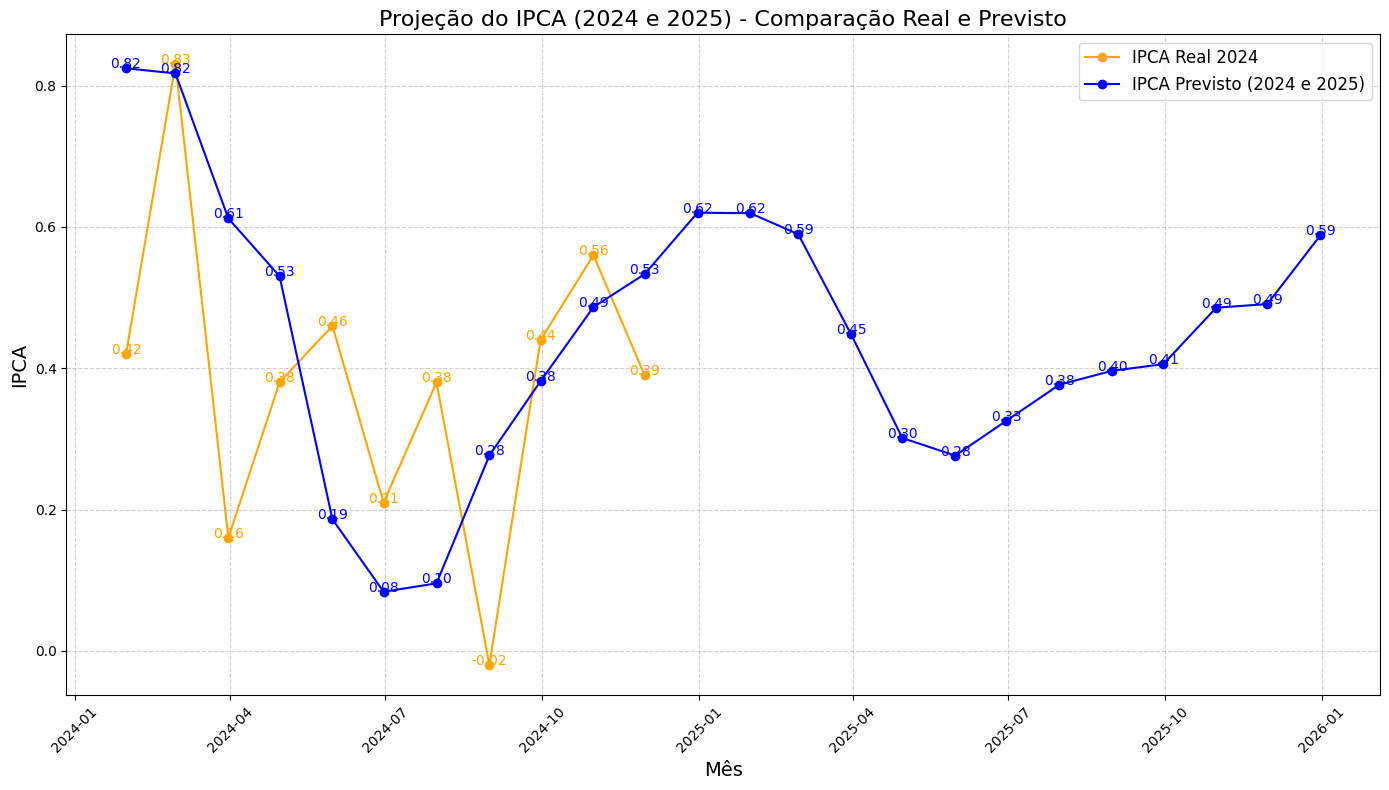

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Supondo que os dados foram normalizados com um scaler
# Reverter a normalização dos valores previstos (necessário se os dados foram escalonados)
y_test_pred_original = scaler.inverse_transform(y_test_pred.reshape(-1, 1)).flatten()

df_original = pd.read_excel('IPCA_ANALISAR.xlsx')  # Carregar os dados originais
df_original['Período'] = pd.to_datetime(df_original['Período'])

# Obter os valores reais do IPCA para 2024
y_real_2024 = df_original[df_original['Período'].dt.year == 2024]['IPCA'].values

# Caso os valores reais de 2024 também precisem ser desnormalizados
y_real_2024_original = scaler.inverse_transform(scaler.transform(y_real_2024.reshape(-1, 1))).flatten()

# Criar um DataFrame para os valores reais de 2024
dates_real_2024 = pd.date_range(start="2024-01-01", periods=len(y_real_2024_original), freq="ME")
df_2024_real = pd.DataFrame({
    'Data': dates_real_2024,
    'IPCA_Real': y_real_2024_original
})

# Criar um DataFrame para os valores previstos (2024 e 2025)
dates_pred = pd.date_range(start="2024-01-01", periods=len(y_test_pred_original), freq="ME")
df_pred = pd.DataFrame({
    'Data': dates_pred,
    'IPCA_Previsto': y_test_pred_original
})

# Filtrar apenas 2024 e 2025 para os valores previstos
df_pred_filtered = df_pred[(df_pred['Data'].dt.year >= 2024) & (df_pred['Data'].dt.year <= 2025)]

# Criar o gráfico
plt.figure(figsize=(14, 8))

# Plotar valores reais de 2024
plt.plot(df_2024_real['Data'], df_2024_real['IPCA_Real'], label='IPCA Real 2024', color='orange', marker='o')

# Adicionar rótulos aos valores reais de 2024
for i, row in df_2024_real.iterrows():
    plt.text(row['Data'], row['IPCA_Real'], f"{row['IPCA_Real']:.2f}", color='orange', fontsize=10, ha='center')

# Plotar valores previstos (2024 e 2025)
plt.plot(df_pred_filtered['Data'], df_pred_filtered['IPCA_Previsto'], label='IPCA Previsto (2024 e 2025)', color='blue', marker='o')

# Adicionar rótulos aos valores previstos
for i, row in df_pred_filtered.iterrows():
    plt.text(row['Data'], row['IPCA_Previsto'], f"{row['IPCA_Previsto']:.2f}", color='blue', fontsize=10, ha='center')

# Personalizar o gráfico
plt.title('Projeção do IPCA (2024 e 2025) - Comparação Real e Previsto', fontsize=16)
plt.xlabel('Mês', fontsize=14)
plt.ylabel('IPCA', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.tight_layout()

# Exibir o gráfico
plt.show()
